In [1]:
!pip install torchsummary

In [2]:
import torch

import torch.nn as nn

import torch.nn.functional as F

import torchvision

import torchvision.transforms as transforms

from torchsummary import summary

import matplotlib.pyplot as plt

import numpy as np

import warnings

import random

from sklearn.manifold import TSNE

from collections import defaultdict

import time

from torch.utils.data import DataLoader, Subset

warnings.filterwarnings("ignore")

## **Q1**

### Utility functions

In [3]:
# preprocess step as given in tutorial

preprocess = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

])



dataset = torchvision.datasets.CIFAR10(root='./data_', train=True, download=True, transform=preprocess)

print(f'Length of dataset: {len(dataset)}')

100%|██████████| 170498071/170498071 [00:02<00:00, 80415383.98it/s]


Extracting ./data_/cifar-10-python.tar.gz to ./data_
Length of dataset: 50000


In [4]:
train_data, val_data, test_data = [], [], []



# To count samples per class

count = defaultdict(int)



# Partitioning the dataset

for image, label in dataset:

    if count[label] < 70:

        train_data.append((image, label))

    elif count[label] < 80:

        val_data.append((image, label))

    elif count[label] < 100:

        test_data.append((image, label))

    

    count[label] += 1



    if sum(count.values()) == 1000:

        break



print(f"Train data: {len(train_data)}, Validation data: {len(val_data)}, Test data: {len(test_data)}")



# Creating DataLoaders

train_data = DataLoader(train_data, batch_size=32, shuffle=True)

val_data = DataLoader(val_data, batch_size=32, shuffle=False)

test_data = DataLoader(test_data, batch_size=32, shuffle=False)

Train data: 700, Validation data: 100, Test data: 174


In [5]:
def train(model, train_data, optimizer):

    model.train()

    criterion = nn.CrossEntropyLoss()

    train_loss = 0.0

    train_acc = 0.0

    train_len = len(train_data)



    for images, labels in train_data:

        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()



        train_loss += loss.item() * images.size(0)

        predicitons = torch.argmax(output, dim=1)

        train_acc += torch.sum(predicitons == labels).item()



    train_loss /= train_len * 32

    train_acc /= train_len * 32



    return train_loss, train_acc

In [6]:
def validate(model, val_data):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    val_loss = 0.0

    val_acc = 0.0

    val_len = len(val_data)



    with torch.no_grad():

        for images, labels in val_data:

            output = model(images)

            loss = criterion(output, labels)



            val_loss += loss.item() * images.size(0)

            predicitons = torch.argmax(output, dim=1)

            val_acc += torch.sum(predicitons == labels).item()



    val_loss /= val_len * 32

    val_acc /= val_len * 32



    return val_loss, val_acc

In [7]:
def test(model, test_data):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    test_loss = 0.0

    test_acc = 0.0

    test_len = len(test_data)



    with torch.no_grad():

        for images, labels in test_data:

            output = model(images)

            loss = criterion(output, labels)



            test_loss += loss.item() * images.size(0)

            predicitons = torch.argmax(output, dim=1)

            test_acc += torch.sum(predicitons == labels).item()



    test_loss /= test_len * 32

    test_acc /= test_len * 32



    return test_loss, test_acc

In [8]:
def run(model, train_data, val_data, test_data, epochs, optimizer, stop_criterion=10):

    best_model = model

    best_val_loss = np.inf

    stop = 0



    train_losses = [] 

    val_losses = []

    train_accs = []

    val_accs= []



    for epoch in range(epochs):

        # Training

        train_loss, train_acc = train(model, train_data, optimizer)

        train_losses.append(train_loss)

        train_accs.append(train_acc)



        # Validation

        val_loss, val_acc = validate(model, val_data)

        val_losses.append(val_loss)

        val_accs.append(val_acc)



        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")

        print(f"Epoch {epoch+1}/{epochs}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

        print("==================================================================================================")

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model = model

            stop = 0

        else:

            stop += 1

            if stop >= stop_criterion:

                print(f"Epoch: {epoch + 1}: Early stopping") 

                break



    # Testing

    test_loss, test_acc = test(best_model, test_data)

    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

    

    return best_model, train_losses, val_losses, test_loss, train_accs, val_accs, test_acc

### **AlexNet**

In [9]:
alexnet = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=False)

print("AlexNet Summary")

print(summary(alexnet, (3, 224, 224)))

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


AlexNet Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 55, 55]          23,296
              ReLU-2           [-1, 64, 55, 55]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
AdaptiveAvgPool2d-14   

In [10]:
optimizer = torch.optim.Adam(alexnet.parameters(), lr=1e-4, weight_decay=1e-5)

start_time_alex = time.perf_counter()

alexnet, train_losses_alex, val_losses_alex, test_loss_alex, train_accs_alex, val_accs_alex, test_acc_alex = run(alexnet, train_data, val_data, test_data, 50, optimizer)

end_time_alex = time.perf_counter()

time_alex = end_time_alex - start_time_alex

Epoch 1/50, Train Loss: 3.8426, Train Accuracy: 0.0810
Epoch 1/50, Val Loss: 1.9708, Val Accuracy: 0.0859
Epoch 2/50, Train Loss: 2.4086, Train Accuracy: 0.1222
Epoch 2/50, Val Loss: 1.8607, Val Accuracy: 0.0781
Epoch 3/50, Train Loss: 2.3053, Train Accuracy: 0.1378
Epoch 3/50, Val Loss: 1.7713, Val Accuracy: 0.1406
Epoch 4/50, Train Loss: 2.1296, Train Accuracy: 0.2088
Epoch 4/50, Val Loss: 1.7218, Val Accuracy: 0.1406
Epoch 5/50, Train Loss: 2.1234, Train Accuracy: 0.2031
Epoch 5/50, Val Loss: 1.6891, Val Accuracy: 0.1797
Epoch 6/50, Train Loss: 1.9963, Train Accuracy: 0.2940
Epoch 6/50, Val Loss: 1.6774, Val Accuracy: 0.1562
Epoch 7/50, Train Loss: 1.9595, Train Accuracy: 0.2955
Epoch 7/50, Val Loss: 1.6382, Val Accuracy: 0.1719
Epoch 8/50, Train Loss: 1.9565, Train Accuracy: 0.2983
Epoch 8/50, Val Loss: 1.5822, Val Accuracy: 0.2031
Epoch 9/50, Train Loss: 1.8246, Train Accuracy: 0.3097
Epoch 9/50, Val Loss: 1.5837, Val Accuracy: 0.1953
Epoch 10/50, Train Loss: 1.7598, Train Accurac

##### 1a. Plot errors

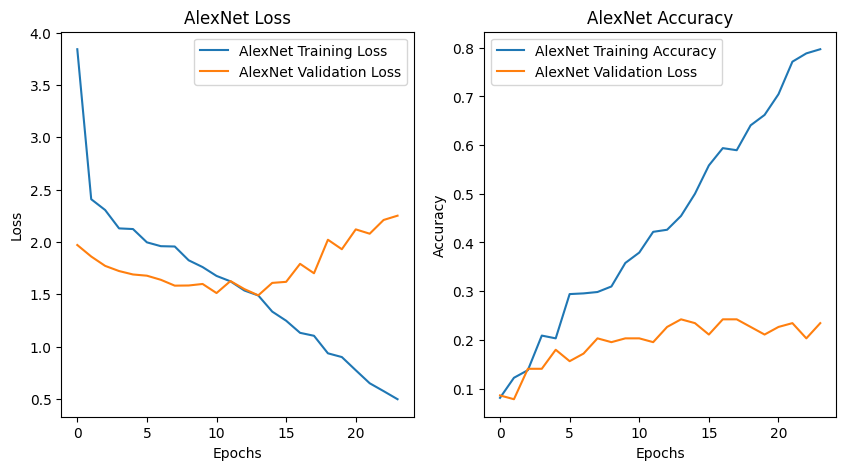

In [11]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.plot(train_losses_alex, label='AlexNet Training Loss')

plt.plot(val_losses_alex, label='AlexNet Validation Loss')

plt.title('AlexNet Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()



plt.subplot(1, 2, 2)

plt.plot(train_accs_alex, label='AlexNet Training Accuracy')

plt.plot(val_accs_alex, label='AlexNet Validation Loss')

plt.title('AlexNet Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

##### 1b. Visualize the activation maps

Activation Map 1: tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
Activation Map 2: tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
Activation Map 3: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3894, 0.3894, 0.1414, 0.1827, 0.2085, 0.1465]])
Activation Map 4: tensor([[0.0725, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.00

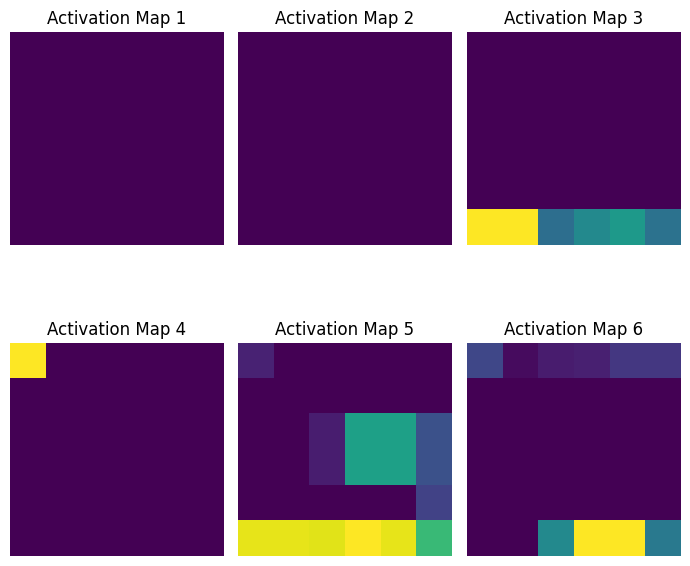

Activation Map 1: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1419, 0.1419, 0.0000, 0.0000],
        [0.0006, 0.0006, 0.0000, 0.0000, 0.0369, 0.0369],
        [0.5483, 0.0238, 0.0000, 0.0724, 0.0724, 0.0369],
        [0.5483, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
Activation Map 2: tensor([[0.4499, 0.2220, 0.0000, 0.0000, 0.0996, 0.2537],
        [0.1725, 0.1322, 0.0000, 0.0000, 0.0000, 0.3534],
        [0.1725, 0.1322, 0.0000, 0.0000, 0.0000, 0.3534],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
Activation Map 3: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.2165, 0.2165, 0.0000],
        [0.0000,

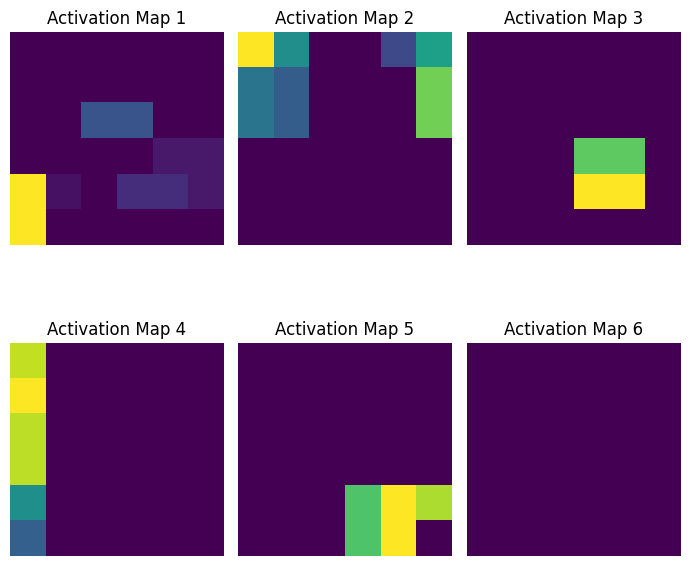

In [12]:
conv_layer_maps_alex = []

pooled_maps_alex = []



with torch.no_grad():

    for batch_idx, (batch_images, _) in enumerate(test_data):

        single_image = batch_images[:1]

        conv_map_alex = alexnet.features(single_image)

        conv_layer_maps_alex.append(conv_map_alex)

        pooled_map_alex = alexnet.avgpool(conv_map_alex)

        pooled_maps_alex.append(pooled_map_alex)



        

plt.figure(figsize=(7, 7))

for i in range(6):

    idx = random.randint(0, 256)

    plt.subplot(2, 3, i + 1)

    plt.imshow(conv_layer_maps_alex[0][0][idx])

    plt.title(f"Activation Map {i + 1}")

    plt.axis('off')

    print(f"Activation Map {i + 1}: {conv_layer_maps_alex[0][0][idx]}")

plt.tight_layout()

plt.show()



plt.figure(figsize=(7, 7))

for i in range(6):

    idx = random.randint(0, 256)

    plt.subplot(2, 3, i + 1)

    plt.imshow(pooled_maps_alex[0][0][idx])

    plt.title(f"Activation Map {i + 1}")

    plt.axis('off')

    print(f"Activation Map {i + 1}: {pooled_maps_alex[0][0][idx]}")

plt.tight_layout()

plt.show()

##### 1c. Report accuracy

In [13]:
print(f"Test accuracy of ResNet: {test_acc_alex}")

Test accuracy of ResNet: 0.3958333333333333


##### 1d. Visualize bottleneck feature

<class 'torch.Tensor'>


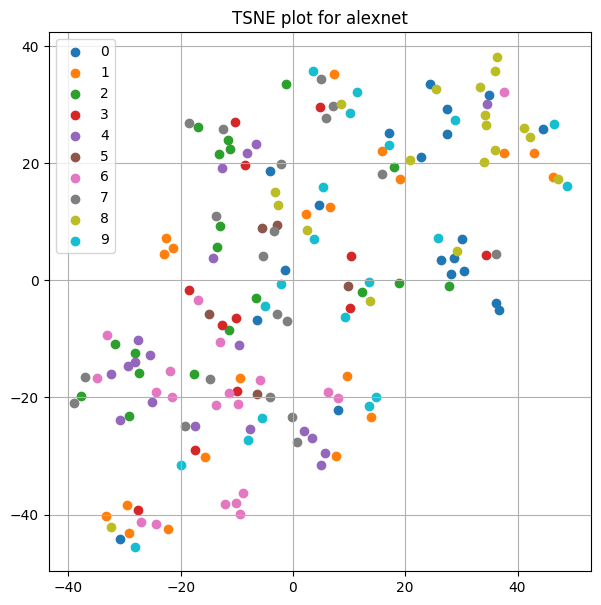

In [14]:
bottleneck_features_alex, targets_alex = [], []

with torch.no_grad():

    for images, labels in test_data:

        # Get the bottleneck features

        bottleneck = alexnet.features(images)

        bottleneck = alexnet.avgpool(bottleneck)

        bottleneck = torch.flatten(bottleneck, 1)

        bottleneck_features_alex.append(bottleneck)

        targets_alex.append(labels)

bottleneck_features_alex = torch.cat(bottleneck_features_alex)

targets_alex = torch.cat(targets_alex)



print(type(bottleneck_features_alex))

embeddings = TSNE(2, init="random", perplexity=3).fit_transform(bottleneck_features_alex)

plt.figure(figsize=(7, 7))

for i in range(10):

    index = np.where(np.array(targets_alex) == i)[0]

    plt.scatter(embeddings[index, 0], embeddings[index, 1], label=str(i))



plt.title("TSNE plot for alexnet")

plt.legend()

plt.grid(True)

plt.show()

### **ResNet**

In [15]:
resnet = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=False)

print("ResNet Summary")

print(summary(resnet, (3, 224, 224)))

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


ResNet Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14    

In [16]:
optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-4, weight_decay=1e-5)

start_time_res = time.perf_counter()

resnet, train_losses_res, val_losses_res, test_loss_res, train_accs_res, val_accs_res, test_acc_res = run(resnet, train_data, val_data, test_data, 50, optimizer)

end_time_res = time.perf_counter()

time_res = end_time_res - start_time_res

Epoch 1/50, Train Loss: 5.3300, Train Accuracy: 0.1605
Epoch 1/50, Val Loss: 3.7360, Val Accuracy: 0.1250
Epoch 2/50, Train Loss: 2.8694, Train Accuracy: 0.3111
Epoch 2/50, Val Loss: 2.5546, Val Accuracy: 0.2188
Epoch 3/50, Train Loss: 1.9667, Train Accuracy: 0.3963
Epoch 3/50, Val Loss: 1.8819, Val Accuracy: 0.2422
Epoch 4/50, Train Loss: 1.6553, Train Accuracy: 0.4645
Epoch 4/50, Val Loss: 1.7298, Val Accuracy: 0.2578
Epoch 5/50, Train Loss: 1.4371, Train Accuracy: 0.4986
Epoch 5/50, Val Loss: 1.8758, Val Accuracy: 0.1797
Epoch 6/50, Train Loss: 1.2387, Train Accuracy: 0.5810
Epoch 6/50, Val Loss: 1.4268, Val Accuracy: 0.2656
Epoch 7/50, Train Loss: 1.0500, Train Accuracy: 0.6449
Epoch 7/50, Val Loss: 1.5002, Val Accuracy: 0.2969
Epoch 8/50, Train Loss: 0.8250, Train Accuracy: 0.7585
Epoch 8/50, Val Loss: 1.4717, Val Accuracy: 0.2891
Epoch 9/50, Train Loss: 0.6233, Train Accuracy: 0.8366
Epoch 9/50, Val Loss: 1.5936, Val Accuracy: 0.2969
Epoch 10/50, Train Loss: 0.4100, Train Accurac

##### 1a. Plot errors

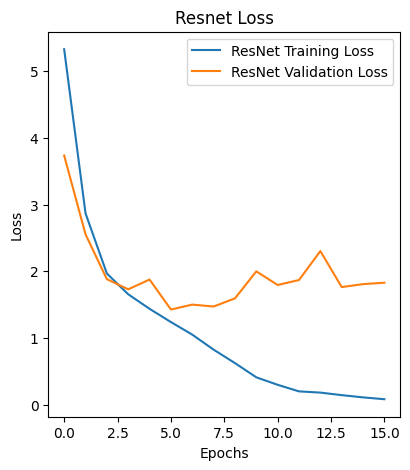

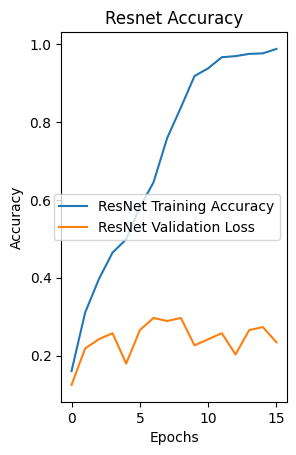

In [17]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.plot(train_losses_res, label='ResNet Training Loss')

plt.plot(val_losses_res, label='ResNet Validation Loss')

plt.title('Resnet Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()



plt.subplot(1, 2, 2)

plt.plot(train_accs_res, label='ResNet Training Accuracy')

plt.plot(val_accs_res, label='ResNet Validation Loss')

plt.title('Resnet Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

##### 1b. Visualize the activation maps

In [18]:
conv_activations, stage1_activations, stage2_activations, stage3_activations = [], [], [], []



with torch.no_grad():

    for idx, (images, _) in enumerate(test_data):

        image = images[:1]

        conv_activation = resnet.conv1(image)

        conv_activations.append(conv_activation)

        activation_after_conv = resnet.bn1(conv_activation)

        activation_after_conv = resnet.relu(activation_after_conv)

        activation_after_conv = resnet.maxpool(activation_after_conv)

        stage1_activation = resnet.layer1(activation_after_conv)

        stage1_activation = resnet.layer2(stage1_activation)

        stage1_activations.append(stage1_activation)

        stage2_activation = resnet.layer3(stage1_activation)

        stage2_activation = resnet.layer4(stage2_activation)

        stage2_activations.append(stage2_activation)

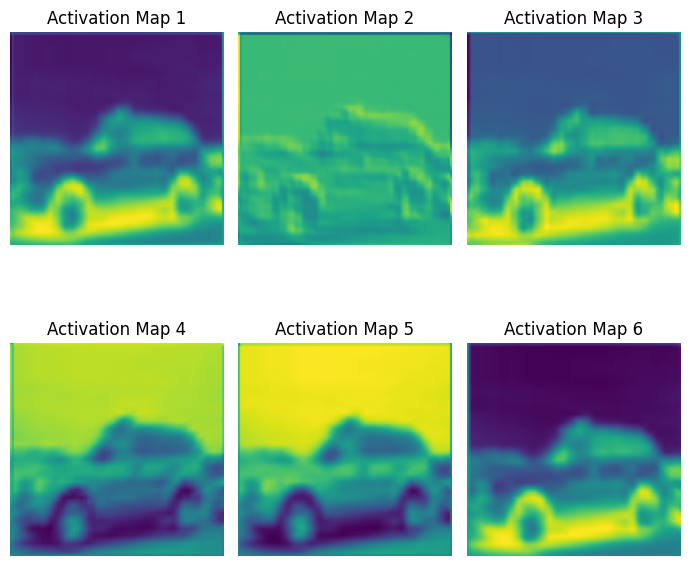

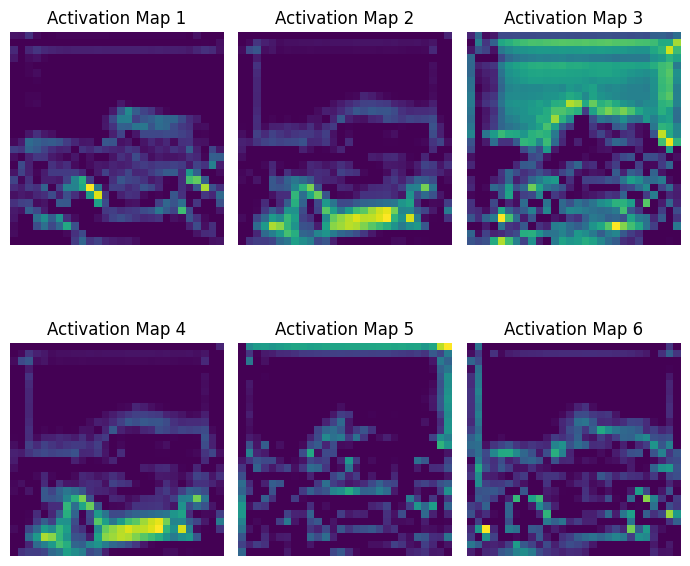

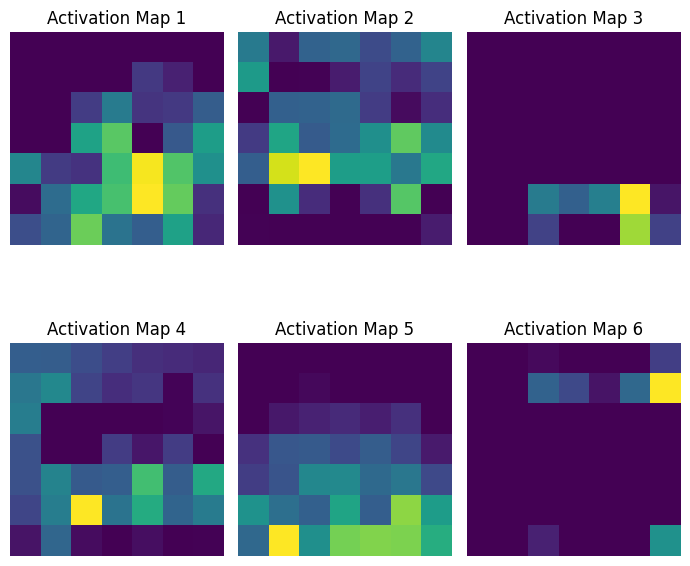

In [19]:
plt.figure(figsize=(7, 7))

for i in range(6):

    idx = random.randint(0, 63)

    plt.subplot(2, 3, i + 1)

    plt.imshow(conv_activations[0][0][idx])

    plt.title(f"Activation Map {i + 1}")

    plt.axis('off')

plt.tight_layout()

plt.show()



plt.figure(figsize=(7, 7))

for i in range(6):

    idx = random.randint(0, 63)

    plt.subplot(2, 3, i + 1)

    plt.imshow(stage1_activations[0][0][idx])

    plt.title(f"Activation Map {i + 1}")

    plt.axis('off')

plt.tight_layout()

plt.show()



plt.figure(figsize=(7, 7))

for i in range(6):

    idx = random.randint(0, 63)

    plt.subplot(2, 3, i + 1)

    plt.imshow(stage2_activations[0][0][idx])

    plt.title(f"Activation Map {i + 1}")

    plt.axis('off')

plt.tight_layout()

plt.show()

##### 1c. Report accuracy

In [20]:
print(f"Test accuracy of ResNet: {test_acc_res}")

Test accuracy of ResNet: 0.3697916666666667


##### 1d. Visualize bottleneck feature

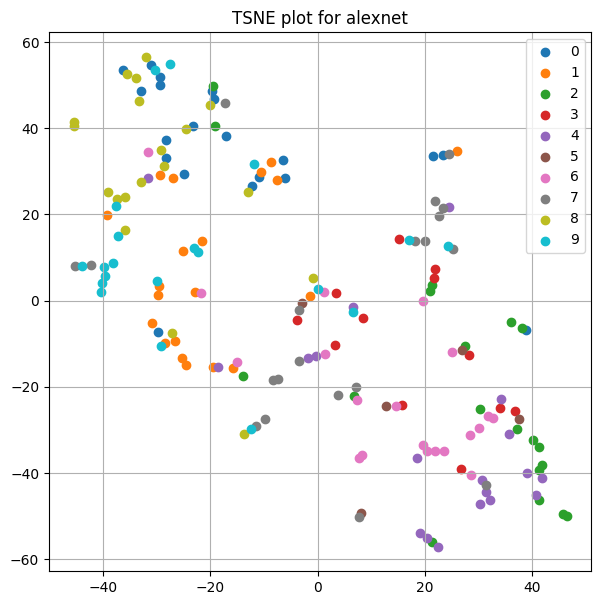

In [21]:
bottleneck_features_res, targets_res = [], []

with torch.no_grad():

    for images, labels in test_data:

        bottleneck = resnet.conv1(images)

        bottleneck = resnet.bn1(bottleneck)

        bottleneck = resnet.relu(bottleneck)

        bottleneck = resnet.maxpool(bottleneck)

        bottleneck = resnet.layer1(bottleneck)

        bottleneck = resnet.layer2(bottleneck)

        bottleneck = resnet.layer3(bottleneck)

        bottleneck = resnet.layer4(bottleneck)

        bottleneck = resnet.avgpool(bottleneck)

        bottleneck = torch.flatten(bottleneck, 1)

        bottleneck_features_res.append(bottleneck)

        targets_res.append(labels)



bottleneck_features_res = torch.cat(bottleneck_features_res)

targets_res = torch.cat(targets_res)



embeddings = TSNE(2, init="random", perplexity=3).fit_transform(bottleneck_features_res)

plt.figure(figsize=(7, 7))

for i in range(10):

    index = np.where(np.array(targets_res) == i)[0]

    plt.scatter(embeddings[index, 0], embeddings[index, 1], label=str(i))



plt.title("TSNE plot for alexnet")

plt.legend()

plt.grid(True)

plt.show()

##### 1e: Compare performance

In [22]:
print(f"{'Model':<10} {'Time Taken':<15} {'Number of Parameters':<20}")



print("-" * 45)



print(f"{'AlexNet':<10} {time_alex:<15.2f} {sum(p.numel() for p in alexnet.parameters()):<20}")

print(f"{'ResNet':<10} {time_res:<15.2f} {sum(p.numel() for p in resnet.parameters()):<20}")

Model      Time Taken      Number of Parameters
---------------------------------------------
AlexNet    1076.43         61100840            
ResNet     1451.68         11689512            


## **Q2**

##### 2.A: Replicate results from tutorial

In [1]:
from io import open

import glob

import os



def findFiles(path): return glob.glob(path)



print(findFiles('data/names/*.txt'))



import unicodedata

import string



all_letters = string.ascii_letters + " .,;'"

n_letters = len(all_letters)



# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427

def unicodeToAscii(s):

    return ''.join(

        c for c in unicodedata.normalize('NFD', s)

        if unicodedata.category(c) != 'Mn'

        and c in all_letters

    )



print(unicodeToAscii('Ślusàrski'))



# Build the category_lines dictionary, a list of names per language

category_lines = {}

all_categories = []



# Read a file and split into lines

def readLines(filename):

    lines = open(filename, encoding='utf-8').read().strip().split('\n')

    return [unicodeToAscii(line) for line in lines]



for filename in findFiles('data/names/*.txt'):

    category = os.path.splitext(os.path.basename(filename))[0]

    all_categories.append(category)

    lines = readLines(filename)

    category_lines[category] = lines



n_categories = len(all_categories)

['data/names\\Arabic.txt', 'data/names\\Chinese.txt', 'data/names\\Czech.txt', 'data/names\\Dutch.txt', 'data/names\\English.txt', 'data/names\\French.txt', 'data/names\\German.txt', 'data/names\\Greek.txt', 'data/names\\Irish.txt', 'data/names\\Italian.txt', 'data/names\\Japanese.txt', 'data/names\\Korean.txt', 'data/names\\Polish.txt', 'data/names\\Portuguese.txt', 'data/names\\Russian.txt', 'data/names\\Scottish.txt', 'data/names\\Spanish.txt', 'data/names\\Vietnamese.txt']
Slusarski


In [2]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


In [3]:
import torch



# Find letter index from all_letters, e.g. "a" = 0

def letterToIndex(letter):

    return all_letters.find(letter)



# Just for demonstration, turn a letter into a <1 x n_letters> Tensor

def letterToTensor(letter):

    tensor = torch.zeros(1, n_letters)

    tensor[0][letterToIndex(letter)] = 1

    return tensor



# Turn a line into a <line_length x 1 x n_letters>,

# or an array of one-hot letter vectors

def lineToTensor(line):

    tensor = torch.zeros(len(line), 1, n_letters)

    for li, letter in enumerate(line):

        tensor[li][0][letterToIndex(letter)] = 1

    return tensor



print(letterToTensor('J'))



print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


In [4]:
import torch.nn as nn

import torch.nn.functional as F



class RNN(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):

        super(RNN, self).__init__()



        self.hidden_size = hidden_size



        self.i2h = nn.Linear(input_size, hidden_size)

        self.h2h = nn.Linear(hidden_size, hidden_size)

        self.h2o = nn.Linear(hidden_size, output_size)

        self.softmax = nn.LogSoftmax(dim=1)



    def forward(self, input, hidden):

        hidden = F.tanh(self.i2h(input) + self.h2h(hidden))

        output = self.h2o(hidden)

        output = self.softmax(output)

        return output, hidden



    def initHidden(self):

        return torch.zeros(1, self.hidden_size)



n_hidden = 128

rnn = RNN(n_letters, n_hidden, n_categories)

In [5]:
input = letterToTensor('A')

hidden = torch.zeros(1, n_hidden)



output, next_hidden = rnn(input, hidden)

In [6]:
input = lineToTensor('Albert')

hidden = torch.zeros(1, n_hidden)



output, next_hidden = rnn(input[0], hidden)

print(output)

tensor([[-2.7757, -2.7744, -2.9806, -2.8081, -2.9315, -2.9512, -2.9448, -2.8607,
         -2.9051, -2.9178, -2.8606, -2.8012, -2.9672, -2.8421, -3.0267, -2.8446,
         -2.9424, -2.9393]], grad_fn=<LogSoftmaxBackward0>)


In [7]:
def categoryFromOutput(output):

    top_n, top_i = output.topk(1)

    category_i = top_i[0].item()

    return all_categories[category_i], category_i



print(categoryFromOutput(output))

('Chinese', 1)


In [8]:
import random



def randomChoice(l):

    return l[random.randint(0, len(l) - 1)]



def randomTrainingExample():

    category = randomChoice(all_categories)

    line = randomChoice(category_lines[category])

    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)

    line_tensor = lineToTensor(line)

    return category, line, category_tensor, line_tensor



for i in range(10):

    category, line, category_tensor, line_tensor = randomTrainingExample()

    print('category =', category, '/ line =', line)

category = Greek / line = Calpis
category = Korean / line = Yim
category = Dutch / line = Snyder
category = Spanish / line = Valdez
category = French / line = Sergeant
category = German / line = Heidrich
category = French / line = Fontaine
category = Italian / line = Bassanelli
category = Japanese / line = Ogiwara
category = Japanese / line = Miyahara


In [9]:
criterion = nn.NLLLoss()

In [10]:
learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn



def train(category_tensor, line_tensor):

    hidden = rnn.initHidden()



    rnn.zero_grad()



    for i in range(line_tensor.size()[0]):

        output, hidden = rnn(line_tensor[i], hidden)



    loss = criterion(output, category_tensor)

    loss.backward()



    # Add parameters' gradients to their values, multiplied by learning rate

    for p in rnn.parameters():

        p.data.add_(p.grad.data, alpha=-learning_rate)



    return output, loss.item()

In [ ]:
import time

import math



n_iters = 5000

print_every = 5000

plot_every = 1000







# Keep track of losses for plotting

current_loss = 0

all_losses = []



def timeSince(since):

    now = time.time()

    s = now - since

    m = math.floor(s / 60)

    s -= m * 60

    return '%dm %ds' % (m, s)



start = time.time()



for iter in range(1, n_iters + 1):

    category, line, category_tensor, line_tensor = randomTrainingExample()

    output, loss = train(category_tensor, line_tensor)

    current_loss += loss



    # Print ``iter`` number, loss, name and guess

    if iter % print_every == 0:

        guess, guess_i = categoryFromOutput(output)

        correct = '✓' if guess == category else '✗ (%s)' % category

        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))



    # Add current loss avg to list of losses

    if iter % plot_every == 0:

        all_losses.append(current_loss / plot_every)

        current_loss = 0

5000 100% (0m 23s) 2.4416 Dunkle / Arabic ✗ (German)


: 

In [ ]:
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker



plt.figure()

plt.plot(all_losses)

In [ ]:
# Keep track of correct guesses in a confusion matrix

confusion = torch.zeros(n_categories, n_categories)

n_confusion = 10000



# Just return an output given a line

def evaluate(line_tensor):

    hidden = rnn.initHidden()



    for i in range(line_tensor.size()[0]):

        output, hidden = rnn(line_tensor[i], hidden)



    return output



# Go through a bunch of examples and record which are correctly guessed

for i in range(n_confusion):

    category, line, category_tensor, line_tensor = randomTrainingExample()

    output = evaluate(line_tensor)

    guess, guess_i = categoryFromOutput(output)

    category_i = all_categories.index(category)

    confusion[category_i][guess_i] += 1



# Normalize by dividing every row by its sum

for i in range(n_categories):

    confusion[i] = confusion[i] / confusion[i].sum()



# Set up plot

fig = plt.figure()

ax = fig.add_subplot(111)

cax = ax.matshow(confusion.numpy())

fig.colorbar(cax)



# Set up axes

ax.set_xticklabels([''] + all_categories, rotation=90)

ax.set_yticklabels([''] + all_categories)



# Force label at every tick

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

ax.yaxis.set_major_locator(ticker.MultipleLocator(1))



# sphinx_gallery_thumbnail_number = 2

plt.show()

##### Modified functions

In [ ]:
def trainLoop(model, category_tensor, line_tensor):

    hidden = model.initHidden()

    model.zero_grad()



    for i in range(line_tensor.size()[0]):

        output, hidden = model(line_tensor[i], hidden)



    loss = criterion(output, category_tensor)

    loss.backward()



    for p in model.parameters():

        p.data.add_(p.grad.data, alpha=-learning_rate)



    return output, loss.item()

In [ ]:
def trainModel(model, category_tensor, line_tensor, n_iters=100000, print_every=5000, plot_every=1000):

    current_loss = 0

    all_losses = []

    start = time.time()



    for iter in range(1, n_iters + 1):

        category, line, category_tensor, line_tensor = randomTrainingExample()

        output, loss = trainLoop(model, category_tensor, line_tensor)

        current_loss += loss



        if iter % print_every == 0:

            guess, guess_i = categoryFromOutput(output)

            correct = '✓' if guess == category else '✗ (%s)' % category

            print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))



        if iter % plot_every == 0:

            all_losses.append(current_loss / plot_every)

            current_loss = 0



    return current_loss, all_losses

In [ ]:
def confusion(model, n_confusion=10000):

    confusion_matrix = torch.zeros(n_categories, n_categories)



    for i in range(n_confusion):

        category, line, category_tensor, line_tensor = randomTrainingExample()

        output = evaluate(line_tensor)

        guess, guess_i = categoryFromOutput(output)

        category_i = all_categories.index(category)

        confusion_matrix[category_i][guess_i] += 1



    for i in range(n_categories):

        confusion_matrix[i] = confusion_matrix[i] / confusion_matrix[i].sum()



    return confusion_matrix

##### 2b. GRU

In [ ]:
class GRU(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):

        super(GRU, self).__init__()

        

        self.hidden_dim = hidden_dim



        self.z_gate = nn.Linear(input_dim + hidden_dim, hidden_dim)  # Update gate \( z \)

        self.r_gate = nn.Linear(input_dim + hidden_dim, hidden_dim)  # Reset gate \( r \)

        self.candidate_layer = nn.Linear(input_dim + hidden_dim, hidden_dim)  # Candidate hidden state \( \tilde{h} \)

        

        self.h2o = nn.Linear(hidden_dim, output_dim)  # Final output layer

        self.softmax = nn.LogSoftmax(dim=1)



    def forward(self, x, h_prev):

        combined = torch.cat((x, h_prev), dim=1)



        z = torch.sigmoid(self.z_gate(combined))  # Update gate

        r = torch.sigmoid(self.r_gate(combined))  # Reset gate



        r_h_prev = r * h_prev

        combined_candidate = torch.cat((x, r_h_prev), dim=1)

        h_tilde = torch.tanh(self.candidate_layer(combined_candidate))  # Candidate hidden state



        h_new = (1 - z) * h_prev + z * h_tilde



        output = self.h2o(h_new)

        output = self.softmax(output)



        return output, h_new



    def initHidden(self):

        return torch.zeros(1, self.hidden_dim)





hidden_units = 128

gru_model = GRU(n_letters, hidden_units, n_categories)

In [ ]:
current_loss_gru, all_losses_gru = trainModel(gru_model, category_tensor, line_tensor)

In [ ]:
plt.figure()

plt.plot(all_losses_gru)

In [ ]:
confusion_gru = confusion(GRU)

fig = plt.figure()

ax = fig.add_subplot(111)

cax = ax.matshow(confusion_gru.numpy())

fig.colorbar(cax)

ax.set_xticklabels([''] + all_categories, rotation=90)

ax.set_yticklabels([''] + all_categories)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

##### 2c. LSTM

In [ ]:
# Naming conventions according to colah's blog post

class LSTM(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):

        super(LSTM, self).__init__()



        self.hidden_size = hidden_size



        self.g = nn.Linear(input_size + hidden_size, hidden_size)  # Candidate

        self.i = nn.Linear(input_size + hidden_size, hidden_size)  # Input gate

        self.f = nn.Linear(input_size + hidden_size, hidden_size)  # Forget gate

        self.o = nn.Linear(input_size + hidden_size, hidden_size)  # Output gate



        self.h2o = nn.Linear(hidden_size, output_size)  # Final output layer

        self.softmax = nn.LogSoftmax(dim=1)



    def forward(self, x, hidden):

        c, h = hidden  # Cell state and hidden state



        combined = torch.cat((x, h), 1)

        i = torch.sigmoid(self.i(combined))  # Input gate

        f = torch.sigmoid(self.f(combined))  # Forget gate

        o = torch.sigmoid(self.o(combined))  # Output gate

        g = torch.tanh(self.g(combined))    # Candidate



        c = f * c + i * g   # Update cell state

        h = o * torch.tanh(c)   # Update hidden state



        y = self.h2o(h) # Final output

        y = self.softmax(y)



        return y, (c, h)



    def initHidden(self):

        return (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size))



n_hidden = 128

lstm = LSTM(n_letters, n_hidden, n_categories)

In [ ]:
current_loss_lstm, all_losses_lstm = trainModel(lstm, category_tensor, line_tensor)

In [ ]:
plt.figure()

plt.plot(all_losses_lstm)

In [ ]:
confusion_lstm = confusion(lstm)

fig = plt.figure()

ax = fig.add_subplot(111)

cax = ax.matshow(confusion_lstm.numpy())

fig.colorbar(cax)

ax.set_xticklabels([''] + all_categories, rotation=90)

ax.set_yticklabels([''] + all_categories)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()